In [1]:
import pandas as pd
import numpy as np
from pybdm import BDM
from pybdm import PartitionRecursive
from statistics import harmonic_mean,geometric_mean
import seaborn as sns
from joblib import delayed, Parallel
import altair as alt

In [2]:
# Load the CSV and apply name mapping
# name_mapping = create_model_name_mapping()
# exp_path = "/Users/alberto/Documents/projects/medLLM/seriesWithLLMs_ext_Aug2025.csv"
exp_path = "/Users/alberto/Documents/projects/medLLM/seriesWithLLMs_ext_Dic2025.csv"
bin_seq_df_input = pd.read_csv(exp_path, encoding='latin-1')
# bin_seq_df_input = rename_model_columns(bin_seq_df_input_raw, name_mapping)
bin_seq_df_input

,sequence,chatgpt_4.5-formula,chatgpt_4.5-formula-eval,chatgpt_4.5-formula-correctness,chatgpt_4.5-formula-copy_seq,chatgpt_4.5-formula-ordinal,deepseek-formula,deepseek-formula-eval,deepseek-formula-correctness,deepseek-formula-copy_seq,...,claude-4.5-program-print,claude-4.5-program-correctness,gemini-3-pro-program,gemini-3-pro-program-eval,gemini-3-pro-program-print,gemini-3-pro-program-correctness,mistral-large-3-program,mistral-large-3-program-eval,mistral-large-3-program-print,mistral-large-3-program-correctness
0,"1,1,0,0,0,1,0,0,0,0,1,0","[""[int(i in [0,1,5,10]) for i in range(12)]"",""...","1,1,0,0,0,1,0,0,0,0,1,0",True,False,True,"[1,1,0,0,0,1,0,0,0,0,1,0]","1,1,0,0,0,1,0,0,0,0,1,0",True,True,...,True,True,"print(1,1,0,0,0,1,0,0,0,0,1,0)","1,1,0,0,0,1,0,0,0,0,1,0",True,True,"print([1,1,0,0,0,1,0,0,0,0,1,0])","1,1,0,0,0,1,0,0,0,0,1,0",True,True
1,"0,0,0,1,0,1,1,0,1,0,1,1","[""[int(i in [3,5,6,8,10,11]) for i in range(12...","0,0,0,1,0,1,1,0,1,0,1,1",True,False,True,"[0,0,0,1,0,1,1,0,1,0,1,1]","0,0,0,1,0,1,1,0,1,0,1,1",True,True,...,True,True,"print(0,0,0,1,0,1,1,0,1,0,1,1)","0,0,0,1,0,1,1,0,1,0,1,1",True,True,"print([0,0,0,1,0,1,1,0,1,0,1,1])","0,0,0,1,0,1,1,0,1,0,1,1",True,True
2,"1,0,0,0,0,1,1,1,1,0,0,1","[""[int(i in [0,5,6,7,8,11]) for i in range(12)...","1,0,0,0,0,1,1,1,1,0,0,1",True,False,True,"[1,0,0,0,0,1,1,1,1,0,0,1]","1,0,0,0,0,1,1,1,1,0,0,1",True,True,...,True,True,"print(1,0,0,0,0,1,1,1,1,0,0,1)","1,0,0,0,0,1,1,1,1,0,0,1",True,True,"print([1,0,0,0,0,1,1,1,1,0,0,1])","1,0,0,0,0,1,1,1,1,0,0,1",True,True
3,"1,1,1,1,1,1,1,1,0,1,0,0","[""[int(i<8 or i==9) for i in range(12)]"",""[1]*...","1,1,1,1,1,1,1,1,0,1,0,0",True,False,True,"[1,1,1,1,1,1,1,1,0,1,0,0]","1,1,1,1,1,1,1,1,0,1,0,0",True,True,...,True,True,"print(1,1,1,1,1,1,1,1,0,1,0,0)","1,1,1,1,1,1,1,1,0,1,0,0",True,True,"print([1,1,1,1,1,1,1,1,0,1,0,0])","1,1,1,1,1,1,1,1,0,1,0,0",True,True
4,"1,0,1,1,0,1,0,1,0,1,0,0","[""[int(i in [0,2,3,5,7,9]) for i in range(12)]...","1,0,1,1,0,1,0,1,0,1,0,0",True,False,True,"[1,0,1,1,0,1,0,1,0,1,0,0]","1,0,1,1,0,1,0,1,0,1,0,0",True,True,...,True,True,"print(1,0,1,1,0,1,0,1,0,1,0,0)","1,0,1,1,0,1,0,1,0,1,0,0",True,True,print([1 if i%2==1 or i==6 else 0 for i in ran...,"1,0,1,1,0,1,0,1,0,1,0,0",True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,"187,218,260,295,301,000,000,000,000,000",***,***,False,False,False,***,***,False,False,...,True,True,"print(187, 218, 260, 295, 301, 314, 379, 410, ...","187,218,260,295,301,000,000,000,000,000",True,True,*not found,*not found,False,False
186,"29,63,95,140,150,190,221,437,482,491",***,***,False,False,False,***,***,False,False,...,True,True,"print(29, 63, 95, 140, 150, 190, 221, 437, 482...","29,63,95,140,150,190,221,437,482,491",True,True,*not found,*not found,False,False
187,"3,11,84,144,156,177,188,199,229,284",***,***,False,False,False,***,***,False,False,...,True,True,"print(3, 11, 84, 144, 156, 177, 188, 199, 229,...","3,11,84,144,156,177,188,199,229,284",True,True,*not found,*not found,False,False
188,"26,94,98,137,176,301,323,330,372,444",***,***,False,False,False,***,***,False,False,...,True,True,"print(26, 94, 98, 137, 176, 301, 323, 330, 372...","26,94,98,137,176,301,323,330,372,444",True,True,*not found,*not found,False,False


In [3]:
bin_seqs = bin_seq_df_input.iloc[:100,:]
int_seqs_1 = bin_seq_df_input.iloc[100:130,:]
int_seqs_2 = bin_seq_df_input.iloc[130:160,:]
int_seqs_3 = bin_seq_df_input.iloc[160:,:]

In [4]:
bin_seq_df=bin_seqs

In [5]:
models = [
    "chatgpt_4.5",
    "o1_mini",
    "claude_3.7",
    "claude_3.5",
    "o1_preview",
    "gemini",
    "cursor_small",
    "gpt_4o_mini",
    "mistral",
    "qwen",
    "deepseek",
    "llama_4_scout",
    "grok_3",
    "qwen3",
    "chatgpt_5",
    "grok4",
    "deepseek_r1_0528",
    "opus_4",
    "mistral_large2405",
    "gemini_2.5_pro",
    "claude_sonnet_4",
    "meta",
    "gpt_4o",
    "grok_4.1",
    "gpt-5.2",
    "claude-4.5",
    "gemini-3-pro",
    "mistral-large-3",
]

In [6]:
def ascii_to_binary_list(text):
    binary_list = []
    for char in text:
        # Convert each character to its binary representation
        binary_representation = format(ord(char), '08b')
        # Extend the binary_list with the numerical digits of the binary representation
        binary_list.extend([int(bit) for bit in binary_representation])
    return np.array(binary_list).astype(np.int8)


In [7]:
def tst_calc(v1,v2):
    v3 = (v2)*np.array([1,0.1,0.01])
    return np.sum(v1[:3]*v3)




def process_sequence(seq_str):
    """
    Process a sequence string to prepare it for BDM calculation.
    - If it's already a binary sequence (0s and 1s), split by commas and convert to int8
    - If it's a numeric sequence, convert each number to binary digits and flatten
    """
    elements = seq_str.split(",")
    # Check if all elements are binary (0 or 1)
    is_binary = all(e.strip() in ['0', '1'] for e in elements)
    
    if is_binary:
        # Already binary, just convert to int8 array
        return np.array(elements).astype(np.int8)
    else:
        # Convert numeric sequence to binary representation
        binary_digits = []
        for num in elements:
            try:
                # Convert to integer and then to binary string (removing '0b' prefix)
                bin_str = bin(int(num.strip()))[2:]
                # Convert each binary digit to int and add to list
                binary_digits.extend([int(digit) for digit in bin_str])
            except ValueError:
                # If conversion fails, use empty list
                pass
        return np.array(binary_digits).astype(np.int8)
    
def get_model_display_name(model_key):
    """Map internal model key to display name using the predefined mapping."""
    model_name_mapping = {
        'gpt_4o': 'ChatGPT-4o',
        'claude_3.5': 'Claude-3.5',
        'gpt_4o_mini': 'ChatGPT-4o-Mini',
        'cursor_small': 'Cursor-Small',
        'gemini': 'Gemini',
        'meta': 'Meta',
        'o1_mini': 'o1-Mini',
        'o1_preview': 'o1-Preview',
        'mistral': 'Mistral',
        'qwen': 'Qwen',
        'grok_3': 'Grok-3',
        'deepseek': 'DeepSeek',
        'claude_3.7': 'Claude-3.7',
        'chatgpt_4.5': 'ChatGPT-4.5',
        'opus_4': 'Claude-Opus-4',
        'claude_sonnet_4': 'Claude-Sonnet-4',
        'gemini_2.5_pro': 'Gemini-2.5-Pro',
        'mistral_large2405': 'Mistral-Large-2405',
        'qwen3': 'Qwen-3',
        'deepseek_r1_0528': 'DeepSeek-R1-0528',
        'grok4': 'Grok-4',
        'llama_4_scout': 'Llama-4-Scout',
        'chatgpt_5': 'ChatGPT-5',
        "grok_4.1": "Grok-4.1",
        "gpt-5.2": "ChatGPT-5.2",
        "claude-4.5": "Claude-4.5",
        "gemini-3-pro": "Gemini-3-Pro",
        "mistral-large-3": "Mistral-Large-3",  
    }
    return model_name_mapping.get(model_key, model_key)

test_vals=[]
bdm = BDM(ndim=1,partition=PartitionRecursive)
for mdl in models:#[:-1]:
    display_name = get_model_display_name(mdl)
    print('processing model: ', display_name)
    sep_df= bin_seq_df[['sequence',f'{mdl}-formula',f'{mdl}-formula-correctness',f'{mdl}-formula-ordinal',f'{mdl}-formula-copy_seq']].copy()
    sep_df["bdm_formula"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df[f'{mdl}-formula'].to_numpy()]
    sep_df["bdm_input"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df['sequence'].to_numpy()]
    
    df_c_n_n = sep_df[sep_df[f"{mdl}-formula-correctness"] & ~sep_df[f"{mdl}-formula-ordinal"] & ~sep_df[f"{mdl}-formula-copy_seq"]]
    df_c_o = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-ordinal"]]
    df_c_p = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-copy_seq"]]
    df_i = sep_df[~sep_df[f"{mdl}-formula-correctness"]]
    tot_elements = np.sum([len(x) for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
    v1=np.array([len(x)/tot_elements for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
    v2 = []
    for x in [df_c_n_n,df_c_o,df_c_p]:
        datax = np.tanh(((x["bdm_input"])/(x["bdm_formula"])).to_numpy())
        if len(datax)>0:
            v2.append(harmonic_mean(datax))
        else:
            v2.append(0)
    v2 = (np.nan_to_num(np.array(v2)))
    tst = tst_calc(v1,v2)
    test_vals.append([display_name]+list(v1)+list(v2)+[tst])


processing model:  ChatGPT-4.5
processing model:  o1-Mini
processing model:  Claude-3.7
processing model:  Claude-3.5
processing model:  o1-Preview
processing model:  Gemini
processing model:  Cursor-Small
processing model:  ChatGPT-4o-Mini
processing model:  Mistral
processing model:  Qwen
processing model:  DeepSeek
processing model:  Llama-4-Scout
processing model:  Grok-3
processing model:  Qwen-3
processing model:  ChatGPT-5
processing model:  Grok-4
processing model:  DeepSeek-R1-0528
processing model:  Claude-Opus-4
processing model:  Mistral-Large-2405
processing model:  Gemini-2.5-Pro
processing model:  Claude-Sonnet-4
processing model:  Meta
processing model:  ChatGPT-4o
processing model:  Grok-4.1
processing model:  ChatGPT-5.2
processing model:  Claude-4.5
processing model:  Gemini-3-Pro
processing model:  Mistral-Large-3


In [8]:


df_ranking = pd.DataFrame(test_vals)
df_ranking.columns = ["Model","p1","p2","p3","p4","r1","r2","r3","tst"]
np.round(df_ranking.sort_values(by=['tst'],ascending=False).set_index(["Model"]),3)



,p1,p2,p3,p4,r1,r2,r3,tst
Model,,,,,,,,
ChatGPT-4.5,0.00,1.00,0.0,0.00,0.000,0.419,0.000,0.042
o1-Mini,0.00,0.64,0.0,0.36,0.000,0.537,0.000,0.034
Claude-3.7,0.00,0.81,0.0,0.19,0.000,0.407,0.000,0.033
Claude-3.5,0.06,0.14,0.0,0.80,0.449,0.428,0.000,0.033
o1-Preview,0.00,0.29,0.0,0.71,0.000,0.423,0.000,0.012
Gemini,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
Cursor-Small,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
ChatGPT-4o-Mini,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
Qwen,0.00,0.00,1.0,0.00,0.000,0.000,0.710,0.007


In [9]:
df_ranking = pd.DataFrame(test_vals)
df_ranking.columns = ["Model","p1","p2","p3","p4","r1","r2","r3","tst"]
np.round(df_ranking.sort_values(by=['tst'],ascending=False).set_index(["Model"]),3)

,p1,p2,p3,p4,r1,r2,r3,tst
Model,,,,,,,,
ChatGPT-4.5,0.00,1.00,0.0,0.00,0.000,0.419,0.000,0.042
o1-Mini,0.00,0.64,0.0,0.36,0.000,0.537,0.000,0.034
Claude-3.7,0.00,0.81,0.0,0.19,0.000,0.407,0.000,0.033
Claude-3.5,0.06,0.14,0.0,0.80,0.449,0.428,0.000,0.033
o1-Preview,0.00,0.29,0.0,0.71,0.000,0.423,0.000,0.012
Gemini,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
Cursor-Small,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
ChatGPT-4o-Mini,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
Qwen,0.00,0.00,1.0,0.00,0.000,0.000,0.710,0.007


### Append ASI

In [10]:
new_row = {'Model': 'ASI', 'p1': 1, 'p2': 0, 'p3': 0, 'p4': 0, 'r1': 1, 'r2': 0, 'r3': 1, 'tst': 1}
df_ranking2 = pd.concat([df_ranking, pd.DataFrame([new_row])], ignore_index=True)
df_ranking2 = df_ranking2.sort_values(by='tst', ascending=False)
np.round(df_ranking2,3)

,Model,p1,p2,p3,p4,r1,r2,r3,tst
28,ASI,1.00,0.00,0.0,0.00,1.000,0.000,1.000,1.000
0,ChatGPT-4.5,0.00,1.00,0.0,0.00,0.000,0.419,0.000,0.042
1,o1-Mini,0.00,0.64,0.0,0.36,0.000,0.537,0.000,0.034
2,Claude-3.7,0.00,0.81,0.0,0.19,0.000,0.407,0.000,0.033
3,Claude-3.5,0.06,0.14,0.0,0.80,0.449,0.428,0.000,0.033
4,o1-Preview,0.00,0.29,0.0,0.71,0.000,0.423,0.000,0.012
5,Gemini,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
6,Cursor-Small,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
7,ChatGPT-4o-Mini,0.00,0.00,1.0,0.00,0.000,0.000,0.762,0.008
8,Mistral,0.00,0.00,1.0,0.00,0.000,0.000,0.710,0.007


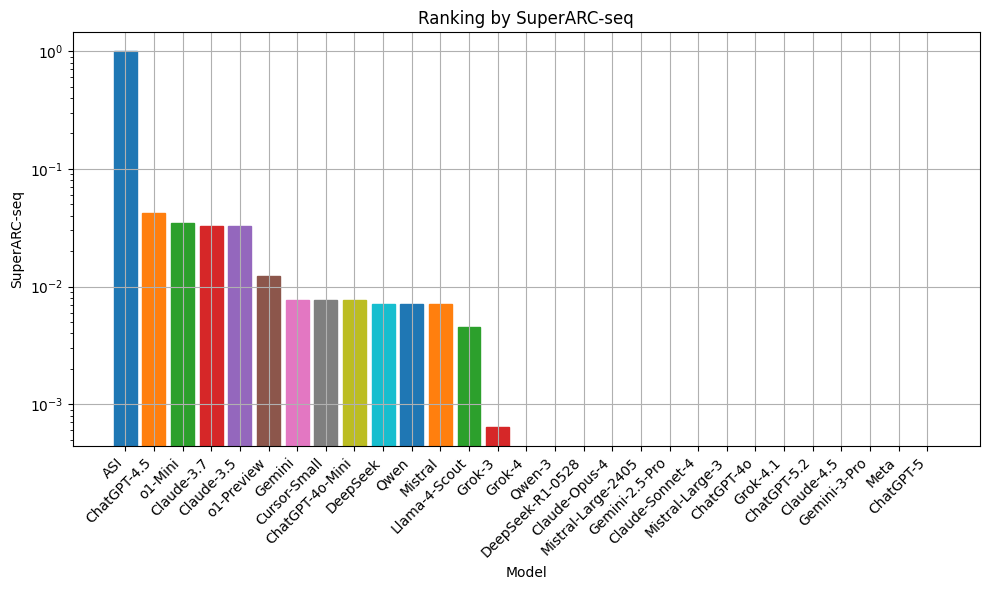

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Sort values in descending order
sorted_df = df_ranking2.sort_values('tst', ascending=False)
# Create bar plot using Model column with default color cycle
bars = plt.bar(range(len(sorted_df)), sorted_df['tst'])
# Set different colors for each bar using default color cycle
for i, bar in enumerate(bars):
    bar.set_color(f'C{i}')
plt.grid(True)
plt.title('Ranking by SuperARC-seq')
plt.xlabel('Model')
plt.ylabel('SuperARC-seq')
# Set y-axis to log scale
plt.yscale('log')
# Set x-tick labels with model names
plt.xticks(range(len(sorted_df)), sorted_df['Model'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

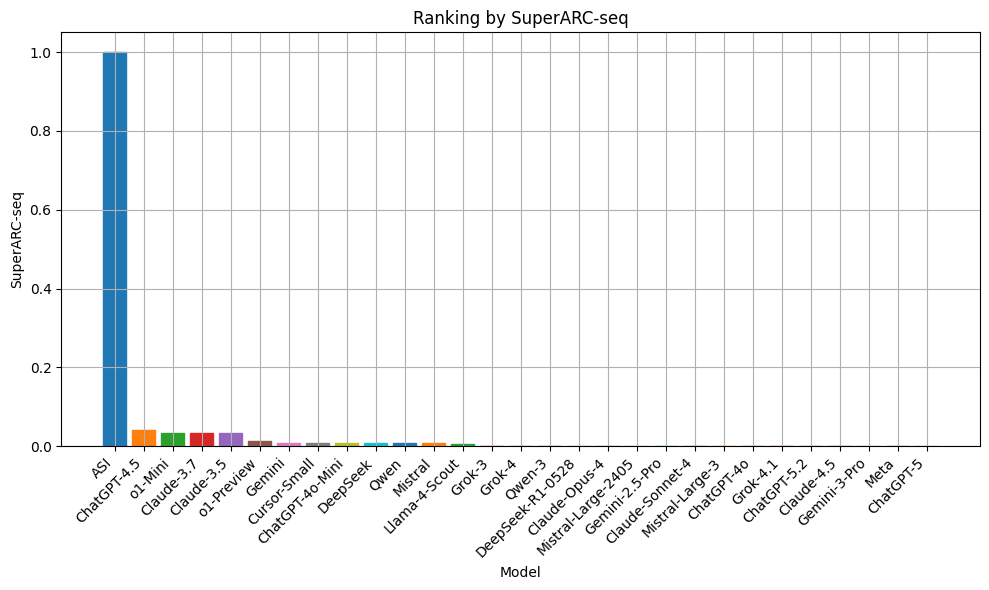

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Sort values in descending order
sorted_df = df_ranking2.sort_values('tst', ascending=False)
# Create bar plot using Model column with default color cycle
bars = plt.bar(range(len(sorted_df)), sorted_df['tst'])
# Set different colors for each bar using default color cycle
for i, bar in enumerate(bars):
    bar.set_color(f'C{i}')
plt.grid(True)
plt.title('Ranking by SuperARC-seq')
plt.xlabel('Model')
plt.ylabel('SuperARC-seq')

# Set x-tick labels with model names
plt.xticks(range(len(sorted_df)), sorted_df['Model'], rotation=45, ha='right')
plt.tight_layout()
# plt.savefig("rankingSuperARC.png", bbox_inches='tight',dpi=600)
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure05.pdf", bbox_inches="tight")
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure05.svg", bbox_inches="tight")

plt.show()



In [13]:
def inner_loop_function(models,bin_seq_df):
    bdm = BDM(ndim=1,partition=PartitionRecursive)
    dict_tst={}
    for mdl in models:#[:-1]:
        sep_df= bin_seq_df[['sequence',f'{mdl}-formula',f'{mdl}-formula-correctness',f'{mdl}-formula-ordinal',f'{mdl}-formula-copy_seq']].copy()
        sep_df["bdm_formula"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df[f'{mdl}-formula'].to_numpy()]
        sep_df["bdm_input"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df['sequence'].to_numpy()]

        df_c_n_n = sep_df[sep_df[f"{mdl}-formula-correctness"] & ~sep_df[f"{mdl}-formula-ordinal"] & ~sep_df[f"{mdl}-formula-copy_seq"]]
        df_c_o = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-ordinal"]]
        df_c_p = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-copy_seq"]]
        df_i = sep_df[~sep_df[f"{mdl}-formula-correctness"]]
        tot_elements = np.sum([len(x) for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v1=np.array([len(x)/tot_elements for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v2 = []
        for x in [df_c_n_n,df_c_o,df_c_p]:
            datax = np.tanh(((x["bdm_input"])/(x["bdm_formula"])).to_numpy())
            if len(datax)>0:
                v2.append(harmonic_mean(datax))
            else:
                v2.append(0)
        v2 = (np.nan_to_num(np.array(v2)))
        tst = tst_calc(v1,v2)
        dict_tst[mdl] = [tst]
    return dict_tst

In [14]:
np.random.seed(42)
rng = np.random.default_rng()

tst_bootstrap=[]
for sz in [25,50,75,100]:
    inpts_bts = []
    for rep_id in range(100):
        idx_v = rng.integers(low=0, high=100, size=sz,dtype = int)
        inpts_bts.append([models,bin_seqs.iloc[idx_v]])

    calcs_lst = Parallel(n_jobs=32)(delayed(inner_loop_function)(*x) for x in inpts_bts)
    dict_tst={}
    for mdl in models:
        dict_tst[mdl]=[]
    for dict_indiv in calcs_lst:
        for ddd in dict_indiv.keys():
            dict_tst[ddd]=dict_tst[ddd]+dict_indiv[ddd]
    tst_bootstrap.append(dict_tst)

In [15]:
lst_dfs=[]
for pp,sz in enumerate([25,50,75,100]): 
    df_interm = pd.DataFrame(tst_bootstrap[pp]).T.reset_index()
    df_interm = df_interm.melt(id_vars=['index'])
    df_interm.loc[:,'variable']=sz
    lst_dfs.append(df_interm)
df_bts = pd.concat(lst_dfs)
df_bts.columns = ["Model","# of Sequences","Test Score"]

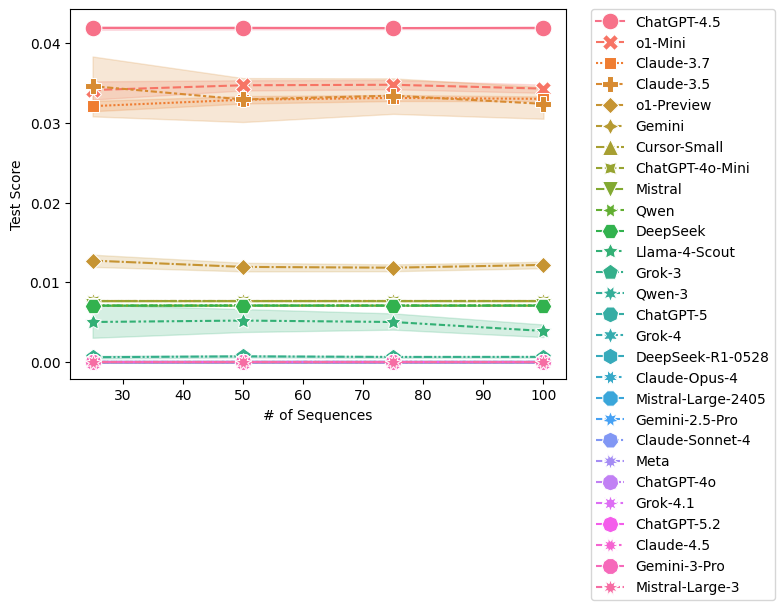

In [16]:
# Map model names to display names
df_bts['Model'] = df_bts['Model'].apply(get_model_display_name)

line_plot = sns.lineplot(data=df_bts, x="# of Sequences", y="Test Score", hue="Model", markers=True, style="Model", markersize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);

import altair as alt

plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure08.pdf", bbox_inches="tight")
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure08.svg", bbox_inches="tight")

# plt.savefig("robustness_tst.png", bbox_inches='tight',dpi=600)8

In [17]:
dfs_study = [bin_seqs, int_seqs_1, int_seqs_2, int_seqs_3]
labels_study = ["Binary", "Integers Type 1","Integers Type 2","Integers Type 3"]

In [18]:
test_vals=[]
bdm = BDM(ndim=1,partition=PartitionRecursive)
for ll,dd in zip(labels_study,dfs_study):  
    for mdl in models:
        sep_df= dd[['sequence',f'{mdl}-formula',f'{mdl}-formula-correctness',f'{mdl}-formula-ordinal',f'{mdl}-formula-copy_seq']].copy()

        df_c_n_n = sep_df[sep_df[f"{mdl}-formula-correctness"] & ~sep_df[f"{mdl}-formula-ordinal"] & ~sep_df[f"{mdl}-formula-copy_seq"]]
        df_c_o = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-ordinal"]]
        df_c_p = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-copy_seq"]]
        df_i = sep_df[~sep_df[f"{mdl}-formula-correctness"]]
        tot_elements = np.sum([len(x) for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v1=np.array([len(x)/tot_elements for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        test_vals.append([mdl]+list(v1)+[ll])

In [19]:
df_stack = pd.DataFrame(test_vals,columns = ["Model","p1","p2","p3","p4","Type"]);

In [20]:
dfs_altair=[]
for pp in ["p1","p2","p3","p4"]:
    df_filt_stack = df_stack.loc[:,pp].to_numpy()
    num_models = len(models)
    df_itermv = pd.DataFrame(df_filt_stack.reshape(len(df_filt_stack)//num_models, num_models, order='F')).T   
    df_itermv.index = models
    df_itermv.columns = labels_study
    dfs_altair.append(df_itermv)

def prep_df(df, name):
    df = df.stack().reset_index()
    df.columns = ['c1', 'c2', 'values']
    df['Prob'] = name
    return df

lst_final_df = []
for pp,nm in enumerate(["p₁","p₂","p₃","p₄"]):
    lst_final_df.append(prep_df(dfs_altair[pp], nm))

df_final = pd.concat(lst_final_df,ignore_index=True)

In [21]:
# Filter data to include only models from index 7 onward
filtered_df = df_final[[x in models[7:] for x in df_final['c1'].to_numpy()]].copy()

# Map model keys to display names
filtered_df['c1'] = filtered_df['c1'].apply(get_model_display_name)

alt.Chart(filtered_df).mark_bar().encode(

    # tell Altair which field to group columns on
    x=alt.X('c2:N', title=None),

    # tell Altair which field to use as Y values and how to calculate
    y=alt.Y('sum(values):Q',
        axis=alt.Axis(
            grid=False,
            title=None)),

    # tell Altair which field to use to use as the set of columns to be  represented in each group
    column=alt.Column('c1:N', title=None),

    # tell Altair which field to use for color segmentation 
    color=alt.Color('Prob:N',
            scale=alt.Scale(
                # make it look pretty with an enjoyable color pallet
                range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f'],
            ),
        ))\
    .configure_view(
        # remove grid lines around column clusters
        strokeOpacity=0    
    )



alt.Chart(...)

In [22]:
# Calculate the midpoint to split models evenly
mid_point = len(models) // 2

# Create a new dataframe with display names
df_display = df_final.copy()
df_display['c1_display'] = df_display['c1'].apply(get_model_display_name)

# First chart with first half of models
chart1 = alt.Chart(df_display[df_display['c1'].isin(models[:mid_point])]).mark_bar().encode(
    # tell Altair which field to group columns on
    x=alt.X('c2:N', title=None),
    # tell Altair which field to use as Y values and how to calculate
    y=alt.Y('sum(values):Q',
        axis=alt.Axis(                                
            grid=False,
            title=None)),
    # tell Altair which field to use to use as the set of columns to be represented in each group
    column=alt.Column('c1_display:N', title=None),
    # tell Altair which field to use for color segmentation
    color=alt.Color('Prob:N',
        scale=alt.Scale(
            # make it look pretty with an enjoyable color pallet
            range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f'],
        ),
    )
)


# Second chart with second half of models
chart2 = alt.Chart(df_display[df_display['c1'].isin(models[mid_point:])]).mark_bar().encode(
    # tell Altair which field to group columns on
    x=alt.X('c2:N', title=None),
    # tell Altair which field to use as Y values and how to calculate
    y=alt.Y('sum(values):Q',
        axis=alt.Axis(
            grid=False,
            title=None)),
    # tell Altair which field to use to use as the set of columns to be represented in each group
    column=alt.Column('c1_display:N', title=None),
    # tell Altair which field to use for color segmentation
    color=alt.Color('Prob:N',
        scale=alt.Scale(
            # make it look pretty with an enjoyable color pallet
            range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f'],
        ),
    )
)

# Display both charts with configuration applied to the concatenated chart
(chart1 & chart2).configure_view(
    # remove grid lines around column clusters
    strokeOpacity=0
)

alt.VConcatChart(...)

In [23]:
# Map model keys to display names
df_final['c1'] = df_final['c1'].apply(get_model_display_name)
df_final 

,c1,c2,values,Prob
0,ChatGPT-4.5,Binary,0.00,p₁
1,ChatGPT-4.5,Integers Type 1,0.00,p₁
2,ChatGPT-4.5,Integers Type 2,0.00,p₁
3,ChatGPT-4.5,Integers Type 3,0.06,p₁
4,o1-Mini,Binary,0.00,p₁
...,...,...,...,...
443,Gemini-3-Pro,Integers Type 3,1.00,p₄
444,Mistral-Large-3,Binary,1.00,p₄
445,Mistral-Large-3,Integers Type 1,1.00,p₄
446,Mistral-Large-3,Integers Type 2,1.00,p₄


In [24]:
#group1

In [25]:
# Calculate the number of models per plot
models_per_plot = len(models) // 3
remainder = len(models) % 3

# Split models into 3 groups
if remainder == 0:
    group1 = models[:models_per_plot]
    group2 = models[models_per_plot:2*models_per_plot]
    group3 = models[2*models_per_plot:]
else:
    group1 = models[:models_per_plot + (1 if remainder > 0 else 0)]
    start2 = len(group1)
    group2 = models[start2:start2 + models_per_plot + (1 if remainder > 1 else 0)]
    group3 = models[len(group1) + len(group2):]

# Map model keys to display names
group1 = [get_model_display_name(m) for m in group1]
group2 = [get_model_display_name(m) for m in group2]
group3 = [get_model_display_name(m) for m in group3]
# Plot 1
plot1 = alt.Chart(df_final[df_final['c1'].isin(group1)]).mark_bar().encode(
    x=alt.X('c2:N', title=None),
    y=alt.Y('sum(values):Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('c1:N', title=None),
    color=alt.Color('Prob:N', scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f']))
).configure_view(strokeOpacity=0)

# Plot 2
plot2 = alt.Chart(df_final[df_final['c1'].isin(group2)]).mark_bar().encode(
    x=alt.X('c2:N', title=None),
    y=alt.Y('sum(values):Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('c1:N', title=None),
    color=alt.Color('Prob:N', scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f']))
).configure_view(strokeOpacity=0)

# Plot 3
plot3 = alt.Chart(df_final[df_final['c1'].isin(group3)]).mark_bar().encode(
    x=alt.X('c2:N', title=None),
    y=alt.Y('sum(values):Q', axis=alt.Axis(gridOpacity=0, title=None)),
    column=alt.Column('c1:N', title=None),
    color=alt.Color('Prob:N', scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f']))
).configure_view(strokeOpacity=0)

# Display individual plots
plot1


alt.Chart(...)

In [26]:
# Calculate the number of models per plot
models_per_plot = len(models) // 3
remainder = len(models) % 3

# Split models into 3 groups
if remainder == 0:
    group1 = models[:models_per_plot]
    group2 = models[models_per_plot:2*models_per_plot]
    group3 = models[2*models_per_plot:]
else:
    group1 = models[:models_per_plot + (1 if remainder > 0 else 0)]
    start2 = len(group1)
    group2 = models[start2:start2 + models_per_plot + (1 if remainder > 1 else 0)]
    group3 = models[len(group1) + len(group2):]

# Map model keys to display names
group1 = [get_model_display_name(m) for m in group1]
group2 = [get_model_display_name(m) for m in group2]
group3 = [get_model_display_name(m) for m in group3]
df_final['c1'] = df_final['c1'].apply(get_model_display_name)

# Plot 1
plot1 = alt.Chart(df_final[df_final['c1'].isin(group1)]).mark_bar().encode(
    x=alt.X('c2:N', title=None),
    y=alt.Y('sum(values):Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('c1:N', title=None),
    color=alt.Color('Prob:N', scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f']))
).configure_view(strokeOpacity=0)

# Plot 2
plot2 = alt.Chart(df_final[df_final['c1'].isin(group2)]).mark_bar().encode(
    x=alt.X('c2:N', title=None),
    y=alt.Y('sum(values):Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('c1:N', title=None),
    color=alt.Color('Prob:N', scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f']))
).configure_view(strokeOpacity=0)

# Plot 3
plot3 = alt.Chart(df_final[df_final['c1'].isin(group3)]).mark_bar().encode(
    x=alt.X('c2:N', title=None),
    y=alt.Y('sum(values):Q', axis=alt.Axis(gridOpacity=0, title=None)),
    column=alt.Column('c1:N', title=None),
    color=alt.Color('Prob:N', scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f']))
).configure_view(strokeOpacity=0)


import altair as alt

plot1.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure06a.pdf")
plot1.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure06a.svg")

plot2.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure06b.pdf")
plot2.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure06b.svg")

plot3.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure06c.pdf")
plot3.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure06c.svg")


# Display individual plots
plot1


alt.Chart(...)

In [27]:
plot2

alt.Chart(...)

In [28]:
plot3

alt.Chart(...)

In [29]:
test_vals_2=[]
bdm = BDM(ndim=1,partition=PartitionRecursive)
for ll,dd in zip(labels_study,dfs_study):  
    for mdl in models:
        sep_df= dd[['sequence',f'{mdl}-formula',f'{mdl}-formula-correctness',f'{mdl}-formula-ordinal',f'{mdl}-formula-copy_seq']].copy()

        sep_df["bdm_formula"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df[f'{mdl}-formula'].to_numpy()]
        sep_df["bdm_input"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df['sequence'].to_numpy()]

        df_c_n_n = sep_df[sep_df[f"{mdl}-formula-correctness"] & ~sep_df[f"{mdl}-formula-ordinal"] & ~sep_df[f"{mdl}-formula-copy_seq"]]
        df_c_o = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-ordinal"]]
        df_c_p = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-copy_seq"]]
        df_i = sep_df[~sep_df[f"{mdl}-formula-correctness"]]
        tot_elements = np.sum([len(x) for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v1=np.array([len(x)/tot_elements for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v2 = []
        for x in [df_c_n_n,df_c_o,df_c_p]:
            datax = np.tanh(((x["bdm_input"])/(x["bdm_formula"])).to_numpy())
            if len(datax)>0:
                v2.append(harmonic_mean(datax))
            else:
                v2.append(0)
        v2 = (np.nan_to_num(np.array(v2)))
        tst = tst_calc(v1,v2)
        test_vals_2.append([mdl]+list(v2)+[tst,ll])

In [30]:
df_stack_2 = pd.DataFrame(test_vals_2,columns = ["Model","r1","r2","r3","tst","Type"]);

In [31]:
dfs_altair_2=[]
for pp in ["tst"]:
    df_filt_stack = df_stack_2.loc[:,pp].to_numpy()
    num_models = len(models)
    df_itermv = pd.DataFrame(df_filt_stack.reshape(len(df_filt_stack)//num_models, num_models)).T
    df_itermv.index = models
    df_itermv.columns = labels_study
    dfs_altair_2.append(df_itermv)

def prep_df(df, name):
    df = df.stack().reset_index()
    df.columns = ['c1', 'c2', 'values']
    df['Metric'] = name
    return df

lst_final_df_2 = []
for pp,nm in enumerate(["𝜑"]):
    lst_final_df_2.append(prep_df(dfs_altair_2[pp], nm))

df_final_2 = pd.concat(lst_final_df_2,ignore_index=True)

In [32]:
# Filter the dataframe to the first 7 models and apply display-name mapping
df_plot = df_final_2[df_final_2['c1'].isin(models[:7])].copy()
df_plot['c1'] = df_plot['c1'].apply(get_model_display_name)

alt.Chart(df_plot).mark_bar().encode(

    # tell Altair which field to group columns on
    x=alt.X('c2:N', title=None),

    # tell Altair which field to use as Y values and how to calculate
    y=alt.Y('sum(values):Q',
        axis=alt.Axis(
            grid=False,
            title=None)),

    # tell Altair which field to use to use as the set of columns to be  represented in each group
    column=alt.Column('c1:N', title=None),

    # tell Altair which field to use for color segmentation 
    color=alt.Color('Metric:N',
            scale=alt.Scale(
                # make it look pretty with an enjoyable color pallet
                range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f'],
            ),
        ))\
    .configure_view(
        # remove grid lines around column clusters
        strokeOpacity=0    
    )

alt.Chart(...)

In [33]:
group1
group1 = [get_model_display_name(m) for m in group1]


In [34]:
df_final_2['c1'] = df_final_2['c1'].apply(get_model_display_name)
df_final_2

,c1,c2,values,Metric
0,ChatGPT-4.5,Binary,0.041914,𝜑
1,ChatGPT-4.5,Integers Type 1,0.580014,𝜑
2,ChatGPT-4.5,Integers Type 2,0.252242,𝜑
3,ChatGPT-4.5,Integers Type 3,0.000000,𝜑
4,o1-Mini,Binary,0.034380,𝜑
...,...,...,...,...
107,Gemini-3-Pro,Integers Type 3,0.000000,𝜑
108,Mistral-Large-3,Binary,0.000000,𝜑
109,Mistral-Large-3,Integers Type 1,0.000000,𝜑
110,Mistral-Large-3,Integers Type 2,0.000000,𝜑


In [35]:
# Get the models subset (from index 7 onwards)
models_subset = models[0:]

# Calculate the number of models per plot
models_per_plot = len(models_subset) // 3
remainder = len(models_subset) % 3

# Split models into 3 groups
if remainder == 0:
    group1 = models_subset[:models_per_plot]
    group2 = models_subset[models_per_plot:2*models_per_plot]
    group3 = models_subset[2*models_per_plot:]
else:
    group1 = models_subset[:models_per_plot + (1 if remainder > 0 else 0)]
    start2 = len(group1)
    group2 = models_subset[start2:start2 + models_per_plot + (1 if remainder > 1 else 0)]
    group3 = models_subset[len(group1) + len(group2):]

# Map model keys to display names
group1 = [get_model_display_name(m) for m in group1]
group2 = [get_model_display_name(m) for m in group2]
group3 = [get_model_display_name(m) for m in group3]
df_final_2['c1'] = df_final_2['c1'].apply(get_model_display_name)
# Plot A
plotA = alt.Chart(df_final_2[[x in group1 for x in df_final_2['c1'].to_numpy()]]).mark_bar().encode(
    x=alt.X('c2:N', title=None),
    y=alt.Y('sum(values):Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('c1:N', title=None),
    color=alt.Color('Metric:N', scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f']))
).configure_view(strokeOpacity=0)

# Plot B
plotB = alt.Chart(df_final_2[[x in group2 for x in df_final_2['c1'].to_numpy()]]).mark_bar().encode(
    x=alt.X('c2:N', title=None),
    y=alt.Y('sum(values):Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('c1:N', title=None),
    color=alt.Color('Metric:N', scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f']))
).configure_view(strokeOpacity=0)

# Plot C
plotC = alt.Chart(df_final_2[[x in group3 for x in df_final_2['c1'].to_numpy()]]).mark_bar().encode(
    x=alt.X('c2:N', title=None),
    y=alt.Y('sum(values):Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('c1:N', title=None),
    color=alt.Color('Metric:N', scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69','#da680f']))
).configure_view(strokeOpacity=0)


plotA.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure07a.pdf")
plotA.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure07a.svg")

plotB.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure07b.pdf")
plotB.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure07b.svg")

plotC.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure07c.pdf")
plotC.save("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure07c.svg")

# Display individual plots
plotA


alt.Chart(...)

In [36]:
plotB


alt.Chart(...)

In [37]:
plotC

alt.Chart(...)

/var/folders/7g/05xwcyss7d1805vwv5mcv_kw0000gn/T/ipykernel_5163/355862645.py:90: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/var/folders/7g/05xwcyss7d1805vwv5mcv_kw0000gn/T/ipykernel_5163/355862645.py:107: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[idx].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=8)


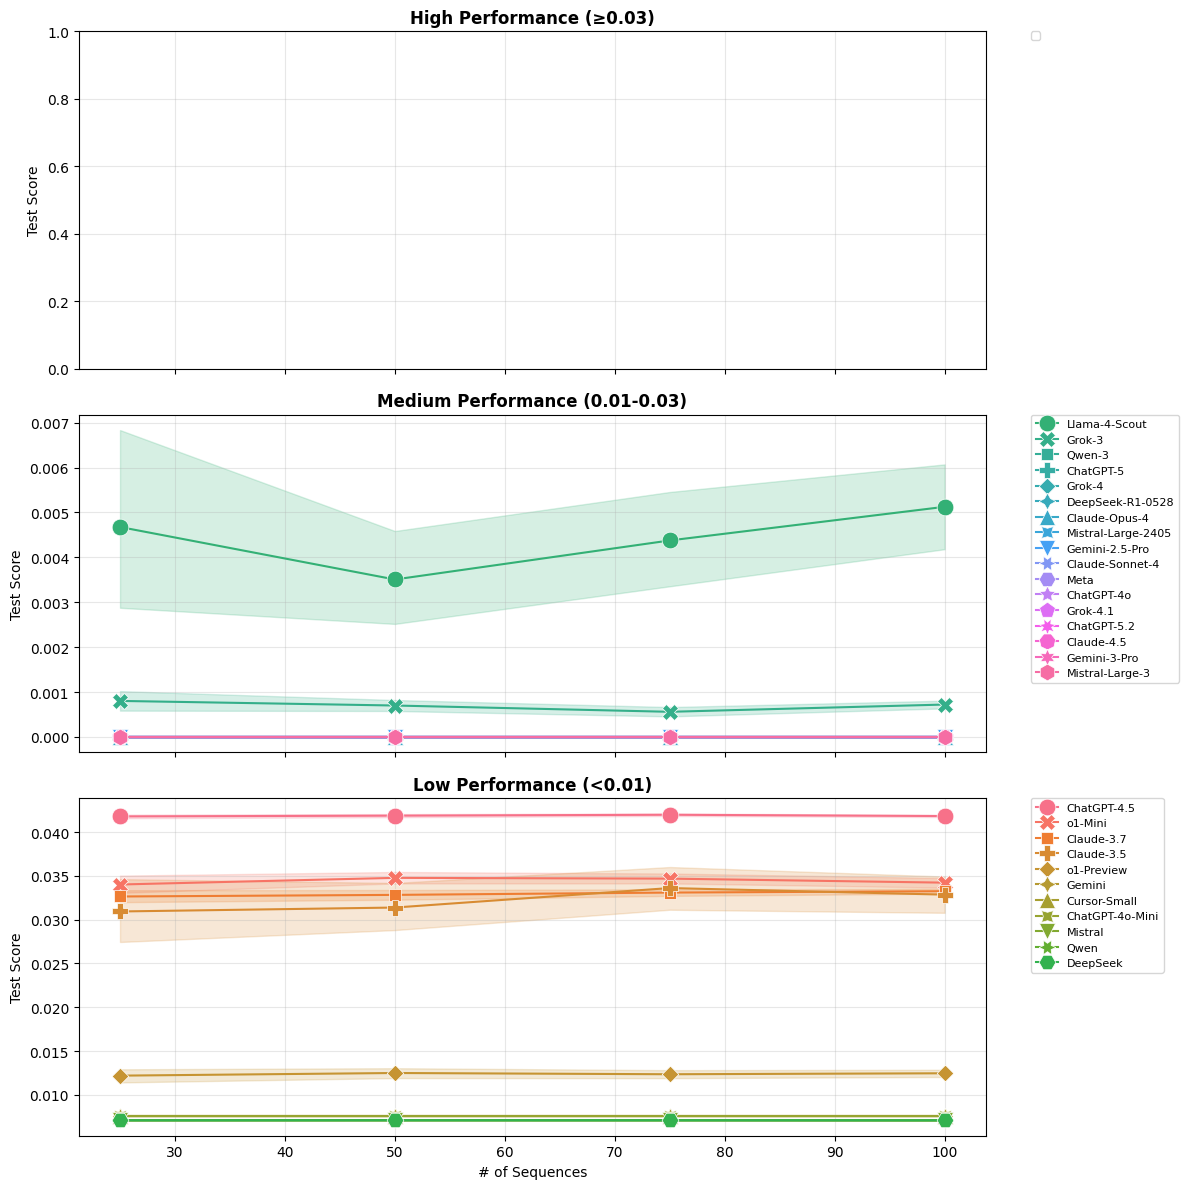

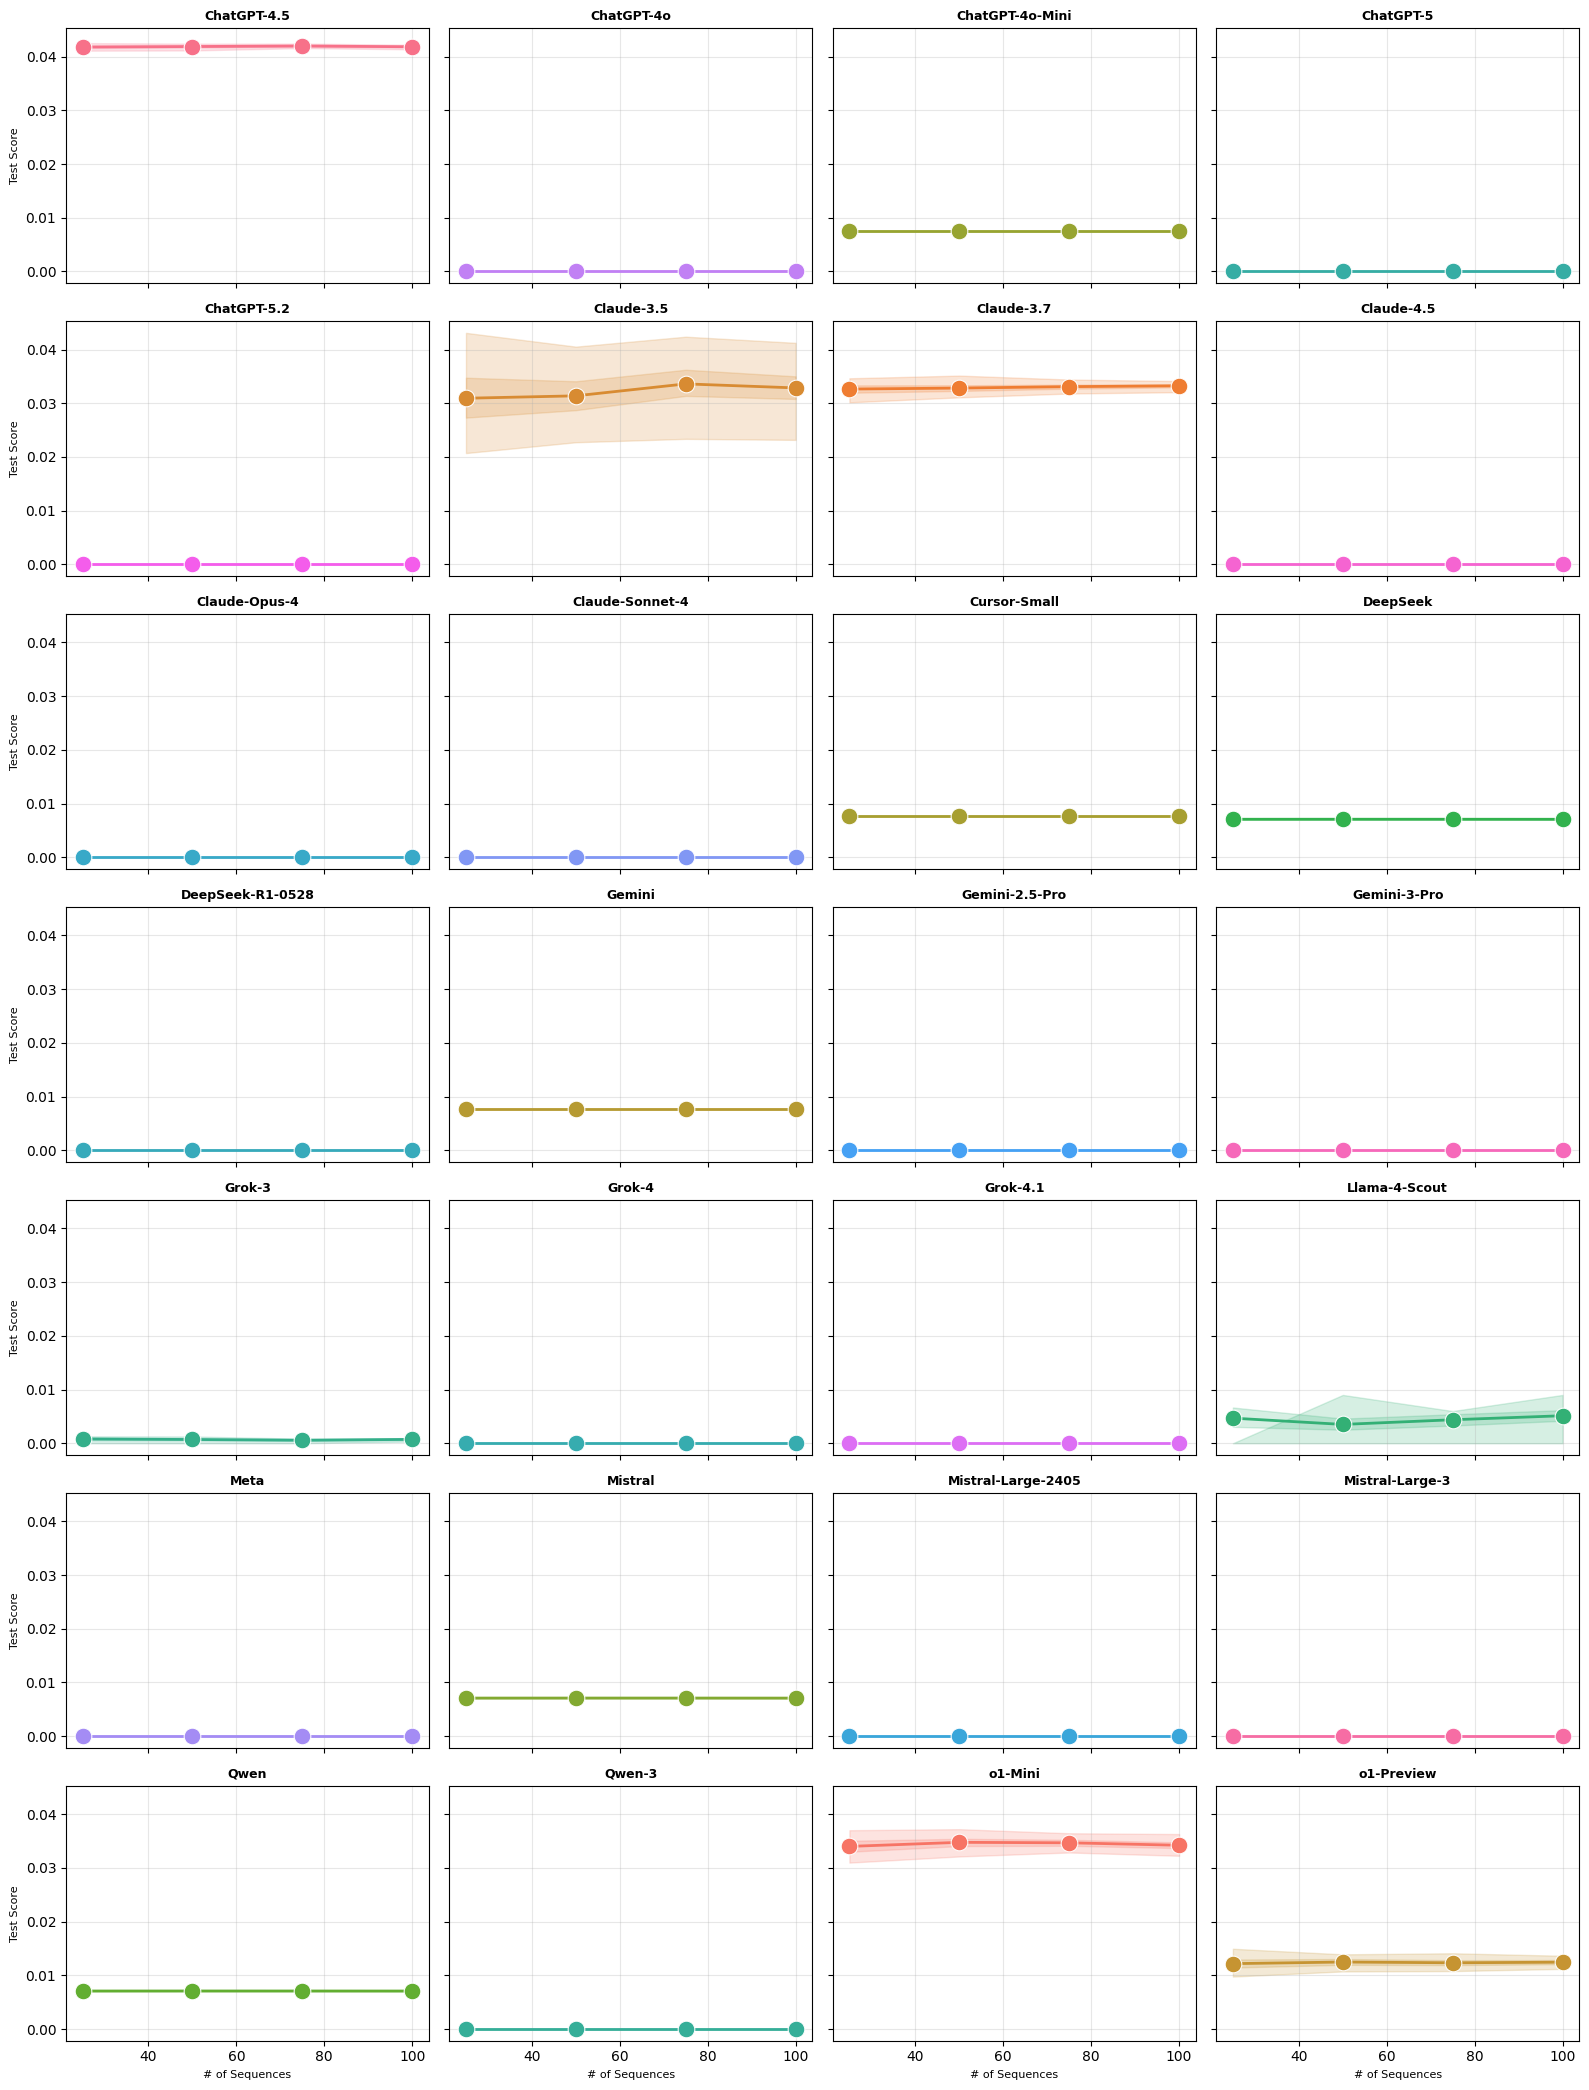

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# Your existing inner_loop_function and data processing code here
# (keeping it the same as your original)

def inner_loop_function(models,bin_seq_df):
    bdm = BDM(ndim=1,partition=PartitionRecursive)
    dict_tst={}
    for mdl in models:#[:-1]:
        sep_df= bin_seq_df[['sequence',f'{mdl}-formula',f'{mdl}-formula-correctness',f'{mdl}-formula-ordinal',f'{mdl}-formula-copy_seq']].copy()
        sep_df["bdm_formula"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df[f'{mdl}-formula'].to_numpy()]
        sep_df["bdm_input"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df['sequence'].to_numpy()]
        df_c_n_n = sep_df[sep_df[f"{mdl}-formula-correctness"] & ~sep_df[f"{mdl}-formula-ordinal"] & ~sep_df[f"{mdl}-formula-copy_seq"]]
        df_c_o = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-ordinal"]]
        df_c_p = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-copy_seq"]]
        df_i = sep_df[~sep_df[f"{mdl}-formula-correctness"]]
        tot_elements = np.sum([len(x) for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v1=np.array([len(x)/tot_elements for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v2 = []
        for x in [df_c_n_n,df_c_o,df_c_p]:
            datax = np.tanh(((x["bdm_input"])/(x["bdm_formula"])).to_numpy())
            if len(datax)>0:
                v2.append(harmonic_mean(datax))
            else:
                v2.append(0)
        v2 = (np.nan_to_num(np.array(v2)))
        tst = tst_calc(v1,v2)
        dict_tst[mdl] = [tst]
    return dict_tst

np.random.seed(42)
rng = np.random.default_rng()
tst_bootstrap=[]
for sz in [25,50,75,100]:
    inpts_bts = []
    for rep_id in range(100):
        idx_v = rng.integers(low=0, high=100, size=sz,dtype = int)
        inpts_bts.append([models,bin_seqs.iloc[idx_v]])
    calcs_lst = Parallel(n_jobs=32)(delayed(inner_loop_function)(*x) for x in inpts_bts)
    dict_tst={}
    for mdl in models:
        dict_tst[mdl]=[]
    for dict_indiv in calcs_lst:
        for ddd in dict_indiv.keys():
            dict_tst[ddd]=dict_tst[ddd]+dict_indiv[ddd]
    tst_bootstrap.append(dict_tst)

lst_dfs=[]
for pp,sz in enumerate([25,50,75,100]): 
    df_interm = pd.DataFrame(tst_bootstrap[pp]).T.reset_index()
    df_interm = df_interm.melt(id_vars=['index'])
    df_interm.loc[:,'variable']=sz
    lst_dfs.append(df_interm)

df_bts = pd.concat(lst_dfs)
df_bts.columns = ["Model","# of Sequences","Test Score"]
# Map model names to display names
df_bts['Model'] = df_bts['Model'].apply(get_model_display_name)

# VERSION 2: Alternative plot - Faceted by performance tiers
# Calculate mean test score for each model to group them
model_means = df_bts.groupby('Model')['Test Score'].mean().sort_values(ascending=False)

# Create performance tiers
def assign_tier(model_name):
    mean_score = model_means[model_name]
    if mean_score >= 0.06 and mean_score < 0.13:
        return 'High Performance (≥0.03)'
    elif mean_score < 0.006:
        return 'Medium Performance (0.01-0.03)'
    else:
        return 'Low Performance (<0.01)'

df_bts['Performance Tier'] = df_bts['Model'].apply(assign_tier)

# Create faceted plot
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

tiers = ['High Performance (≥0.03)', 'Medium Performance (0.01-0.03)', 'Low Performance (<0.01)']
colors = sns.color_palette("husl", len(df_bts['Model'].unique()))
model_color_map = dict(zip(df_bts['Model'].unique(), colors))

for idx, tier in enumerate(tiers):
    tier_data = df_bts[df_bts['Performance Tier'] == tier]
    
    sns.lineplot(
        data=tier_data,
        x="# of Sequences",
        y="Test Score",
        hue="Model",
        ax=axes[idx],
        markers=True,
        style="Model",
        dashes=False,
        markersize=12,  # Increased by 50% from 8
        palette=model_color_map,
        markeredgewidth=0.5,
        markeredgecolor='white'
    )
    
    axes[idx].set_title(tier, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Test Score', fontsize=10)
    axes[idx].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize=8)
    axes[idx].grid(True, alpha=0.3)

axes[2].set_xlabel('# of Sequences', fontsize=10)
plt.tight_layout()
# plt.savefig("robustness_tst_faceted.png", bbox_inches='tight', dpi=600)
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure08.pdf", bbox_inches="tight")
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure08.svg", bbox_inches="tight")
plt.show()

# VERSION 3: Alternative plot - Small multiples with one model per subplot
n_models = len(df_bts['Model'].unique())
ncols = 4
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, model in enumerate(sorted(df_bts['Model'].unique())):
    model_data = df_bts[df_bts['Model'] == model]
    
    sns.lineplot(
        data=model_data,
        x="# of Sequences",
        y="Test Score",
        ax=axes[idx],
        marker='o',
        markersize=12,  # Increased by 50% from 8
        linewidth=2,
        color=model_color_map[model]
    )
    
    # Add confidence interval
    axes[idx].fill_between(
        [25, 50, 75, 100],
        model_data.groupby('# of Sequences')['Test Score'].quantile(0.25),
        model_data.groupby('# of Sequences')['Test Score'].quantile(0.75),
        alpha=0.2,
        color=model_color_map[model]
    )
    
    axes[idx].set_title(model, fontsize=9, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlabel('# of Sequences' if idx >= (nrows-1)*ncols else '', fontsize=8)
    axes[idx].set_ylabel('Test Score' if idx % ncols == 0 else '', fontsize=8)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
#plt.savefig("robustness_tst_small_multiples.png", bbox_inches='tight', dpi=600)
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure08-all.pdf", bbox_inches="tight")
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure08-all.svg", bbox_inches="tight")
plt.show()

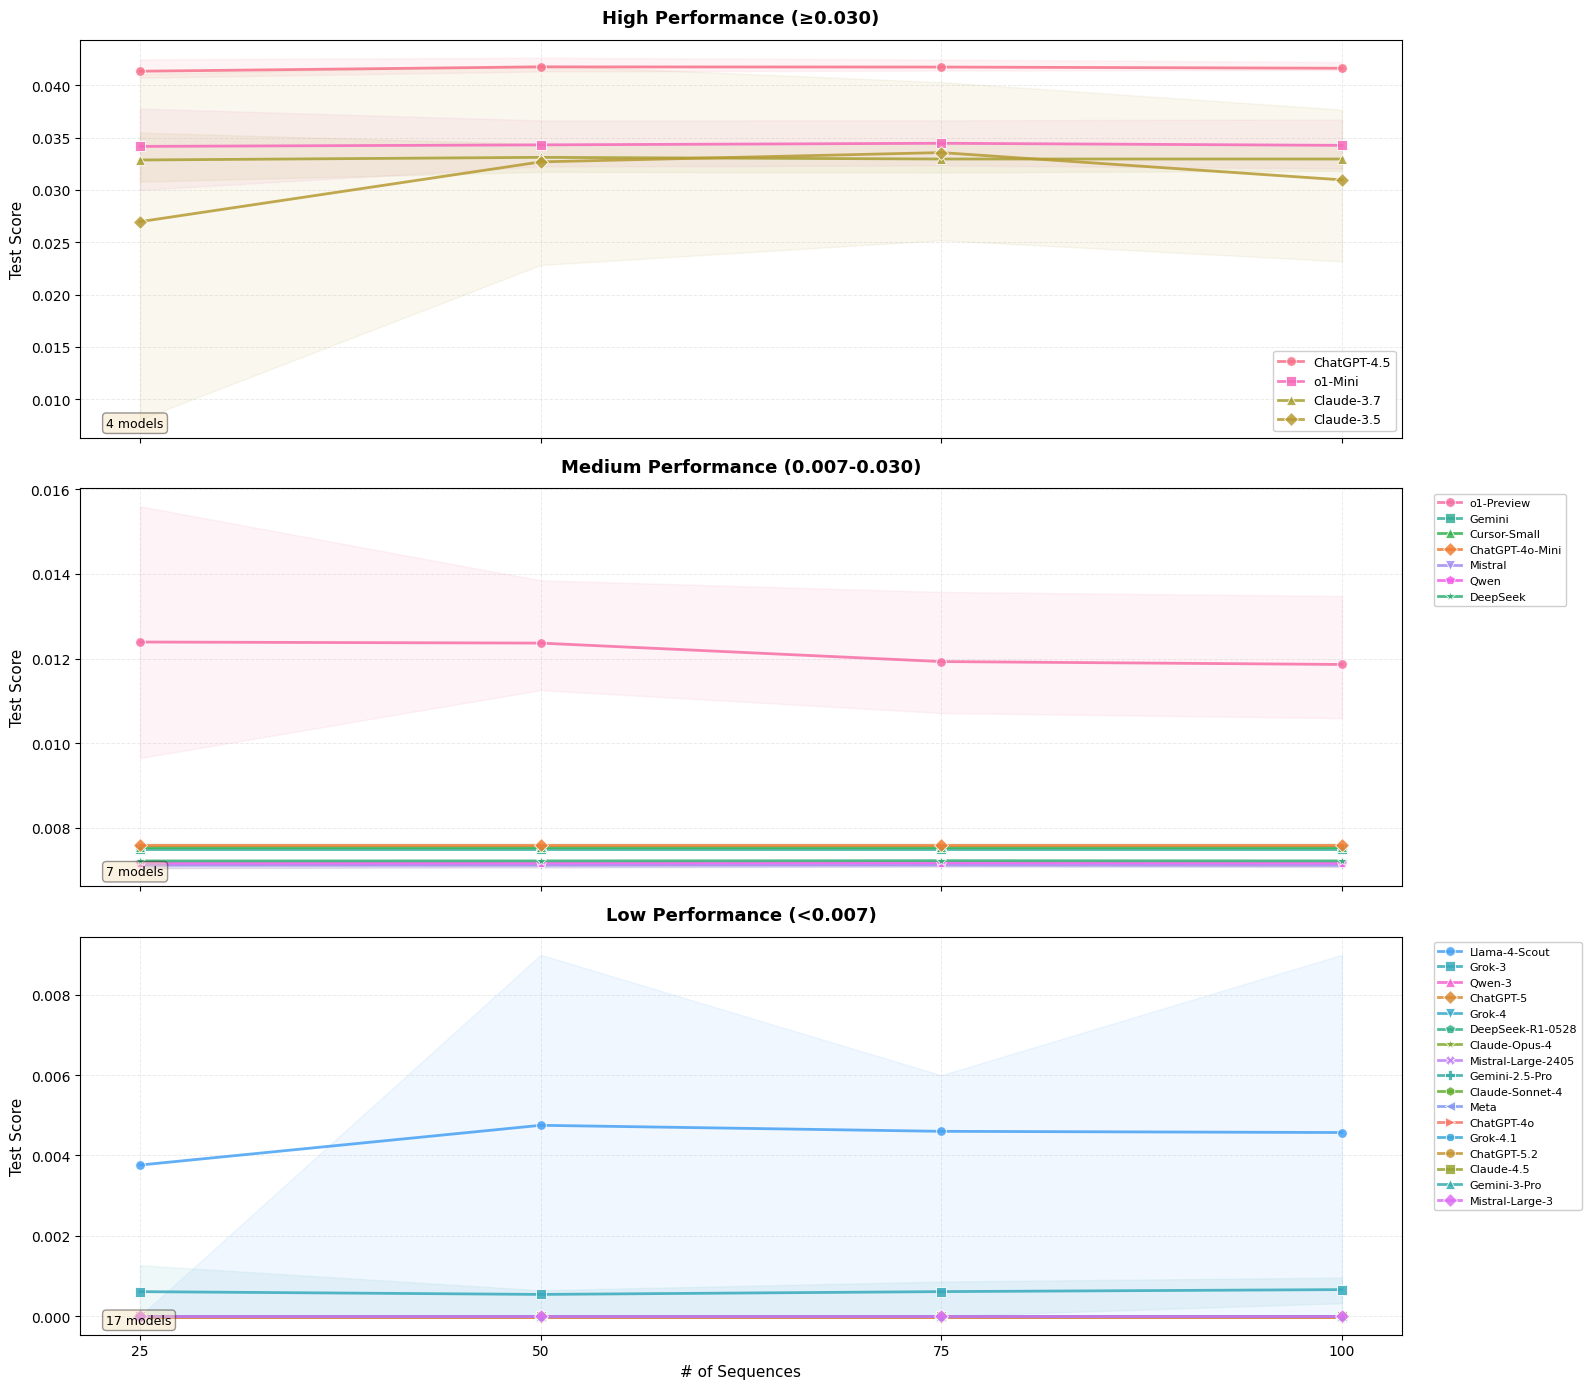


Model Performance Summary by Tier:

High Performance (≥0.030) (4 models):
  • ChatGPT-4.5                     Mean: 0.041814  Std: 0.000909
  • o1-Mini                         Mean: 0.034392  Std: 0.004026
  • Claude-3.7                      Mean: 0.032966  Std: 0.002469
  • Claude-3.5                      Mean: 0.030939  Std: 0.015364

Medium Performance (0.007-0.030) (7 models):
  • o1-Preview                      Mean: 0.012312  Std: 0.002774
  • Gemini                          Mean: 0.007616  Std: 0.000000
  • Cursor-Small                    Mean: 0.007616  Std: 0.000000
  • ChatGPT-4o-Mini                 Mean: 0.007616  Std: 0.000000
  • Mistral                         Mean: 0.007097  Std: 0.000039
  • Qwen                            Mean: 0.007097  Std: 0.000039
  • DeepSeek                        Mean: 0.007097  Std: 0.000039

Low Performance (<0.007) (17 models):
  • Llama-4-Scout                   Mean: 0.004436  Std: 0.006376
  • Grok-3                          Mean: 0.0006

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# Your existing inner_loop_function and data processing code here
# (keeping it the same as your original)

def inner_loop_function(models,bin_seq_df):
    bdm = BDM(ndim=1,partition=PartitionRecursive)
    dict_tst={}
    for mdl in models:#[:-1]:
        sep_df= bin_seq_df[['sequence',f'{mdl}-formula',f'{mdl}-formula-correctness',f'{mdl}-formula-ordinal',f'{mdl}-formula-copy_seq']].copy()
        sep_df["bdm_formula"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df[f'{mdl}-formula'].to_numpy()]
        sep_df["bdm_input"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df['sequence'].to_numpy()]
        df_c_n_n = sep_df[sep_df[f"{mdl}-formula-correctness"] & ~sep_df[f"{mdl}-formula-ordinal"] & ~sep_df[f"{mdl}-formula-copy_seq"]]
        df_c_o = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-ordinal"]]
        df_c_p = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-copy_seq"]]
        df_i = sep_df[~sep_df[f"{mdl}-formula-correctness"]]
        tot_elements = np.sum([len(x) for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v1=np.array([len(x)/tot_elements for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v2 = []
        for x in [df_c_n_n,df_c_o,df_c_p]:
            datax = np.tanh(((x["bdm_input"])/(x["bdm_formula"])).to_numpy())
            if len(datax)>0:
                v2.append(harmonic_mean(datax))
            else:
                v2.append(0)
        v2 = (np.nan_to_num(np.array(v2)))
        tst = tst_calc(v1,v2)
        dict_tst[mdl] = [tst]
    return dict_tst

np.random.seed(42)
rng = np.random.default_rng()
tst_bootstrap=[]
for sz in [25,50,75,100]:
    inpts_bts = []
    for rep_id in range(100):
        idx_v = rng.integers(low=0, high=100, size=sz,dtype = int)
        inpts_bts.append([models,bin_seqs.iloc[idx_v]])
    calcs_lst = Parallel(n_jobs=32)(delayed(inner_loop_function)(*x) for x in inpts_bts)
    dict_tst={}
    for mdl in models:
        dict_tst[mdl]=[]
    for dict_indiv in calcs_lst:
        for ddd in dict_indiv.keys():
            dict_tst[ddd]=dict_tst[ddd]+dict_indiv[ddd]
    tst_bootstrap.append(dict_tst)

lst_dfs=[]
for pp,sz in enumerate([25,50,75,100]): 
    df_interm = pd.DataFrame(tst_bootstrap[pp]).T.reset_index()
    df_interm = df_interm.melt(id_vars=['index'])
    df_interm.loc[:,'variable']=sz
    lst_dfs.append(df_interm)

df_bts = pd.concat(lst_dfs)
df_bts.columns = ["Model","# of Sequences","Test Score"]
# Map model names to display names
df_bts['Model'] = df_bts['Model'].apply(get_model_display_name)

# Calculate mean test score for each model
model_means = df_bts.groupby('Model')['Test Score'].mean().sort_values(ascending=False)

# Assign broad performance category
def assign_broad_tier(model_name):
    mean_score = model_means[model_name]
    if mean_score >= 0.030:
        return 'High'
    elif mean_score >= 0.007:
        return 'Medium'
    else:
        return 'Low'

df_bts['Broad_Tier'] = df_bts['Model'].apply(assign_broad_tier)

# Create the plot with 3 main tiers, but use offset plotting within each tier
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

tiers = ['High', 'Medium', 'Low']
tier_titles = {
    'High': 'High Performance (≥0.030)',
    'Medium': 'Medium Performance (0.007-0.030)',
    'Low': 'Low Performance (<0.007)'
}

# Create color palette
all_models = sorted(df_bts['Model'].unique())
colors = sns.color_palette("husl", len(all_models))
model_color_map = dict(zip(all_models, colors))

# Different markers
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X', 'P', 'h', '<', '>', '8']

for idx, tier in enumerate(tiers):
    tier_data = df_bts[df_bts['Broad_Tier'] == tier]
    tier_models = sorted(tier_data['Model'].unique(), 
                        key=lambda x: model_means[x], 
                        reverse=True)
    
    n_models = len(tier_models)
    
    if n_models == 0:
        axes[idx].text(0.5, 0.5, 'No models in this tier', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        continue
    
    # Calculate vertical offset to separate overlapping lines
    # Models will be slightly offset vertically for visibility
    for model_id, model in enumerate(tier_models):
        model_data = tier_data[tier_data['Model'] == model]
        
        # Calculate statistics
        mean_scores = model_data.groupby('# of Sequences')['Test Score'].mean()
        std_scores = model_data.groupby('# of Sequences')['Test Score'].std()
        ci_lower = model_data.groupby('# of Sequences')['Test Score'].quantile(0.25)
        ci_upper = model_data.groupby('# of Sequences')['Test Score'].quantile(0.75)
        
        # Apply small vertical offset based on position in sorted list
        # This spreads overlapping lines slightly
        offset_factor = 0.0001 if tier == 'High' else (0.00005 if tier == 'Medium' else 0.000002)
        vertical_offset = (model_id - n_models/2) * offset_factor
        
        # Plot with offset
        axes[idx].plot(
            mean_scores.index,
            mean_scores.values + vertical_offset,
            marker=markers[model_id % len(markers)],
            markersize=7,
            linewidth=2,
            label=model,
            color=model_color_map[model],
            markeredgewidth=0.7,
            markeredgecolor='white',
            alpha=0.85
        )
        
        # Add very subtle confidence band (without offset for accuracy)
        axes[idx].fill_between(
            mean_scores.index,
            ci_lower.values,
            ci_upper.values,
            alpha=0.08,
            color=model_color_map[model]
        )
    
    # Formatting
    axes[idx].set_title(tier_titles[tier], fontsize=13, fontweight='bold', pad=12)
    axes[idx].set_ylabel('Test Score', fontsize=11)
    axes[idx].grid(True, alpha=0.25, linestyle='--', linewidth=0.7)
    
    # Smart legend placement
    if n_models <= 6:
        axes[idx].legend(loc='best', fontsize=9, framealpha=0.95, ncol=1)
    else:
        axes[idx].legend(bbox_to_anchor=(1.02, 1), loc='upper left', 
                        fontsize=8, framealpha=0.95, ncol=1)
    
    # Add model count annotation
    axes[idx].text(0.02, 0.02, f'{n_models} model{"s" if n_models != 1 else ""}',
                  transform=axes[idx].transAxes,
                  fontsize=9, verticalalignment='bottom',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

axes[-1].set_xlabel('# of Sequences', fontsize=11)
axes[-1].set_xticks([25, 50, 75, 100])

plt.tight_layout()
plt.savefig("robustness_tst_faceted.png", bbox_inches='tight', dpi=600)
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure08.pdf", bbox_inches="tight")
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure08.svg", bbox_inches="tight")
plt.show()

# Print summary statistics
print("\nModel Performance Summary by Tier:")
print("=" * 80)
for tier in tiers:
    tier_models = df_bts[df_bts['Broad_Tier'] == tier]['Model'].unique()
    if len(tier_models) > 0:
        print(f"\n{tier_titles[tier]} ({len(tier_models)} models):")
        for model in sorted(tier_models, key=lambda x: model_means[x], reverse=True):
            mean = model_means[model]
            std = df_bts[df_bts['Model'] == model]['Test Score'].std()
            print(f"  • {model:30s}  Mean: {mean:.6f}  Std: {std:.6f}")

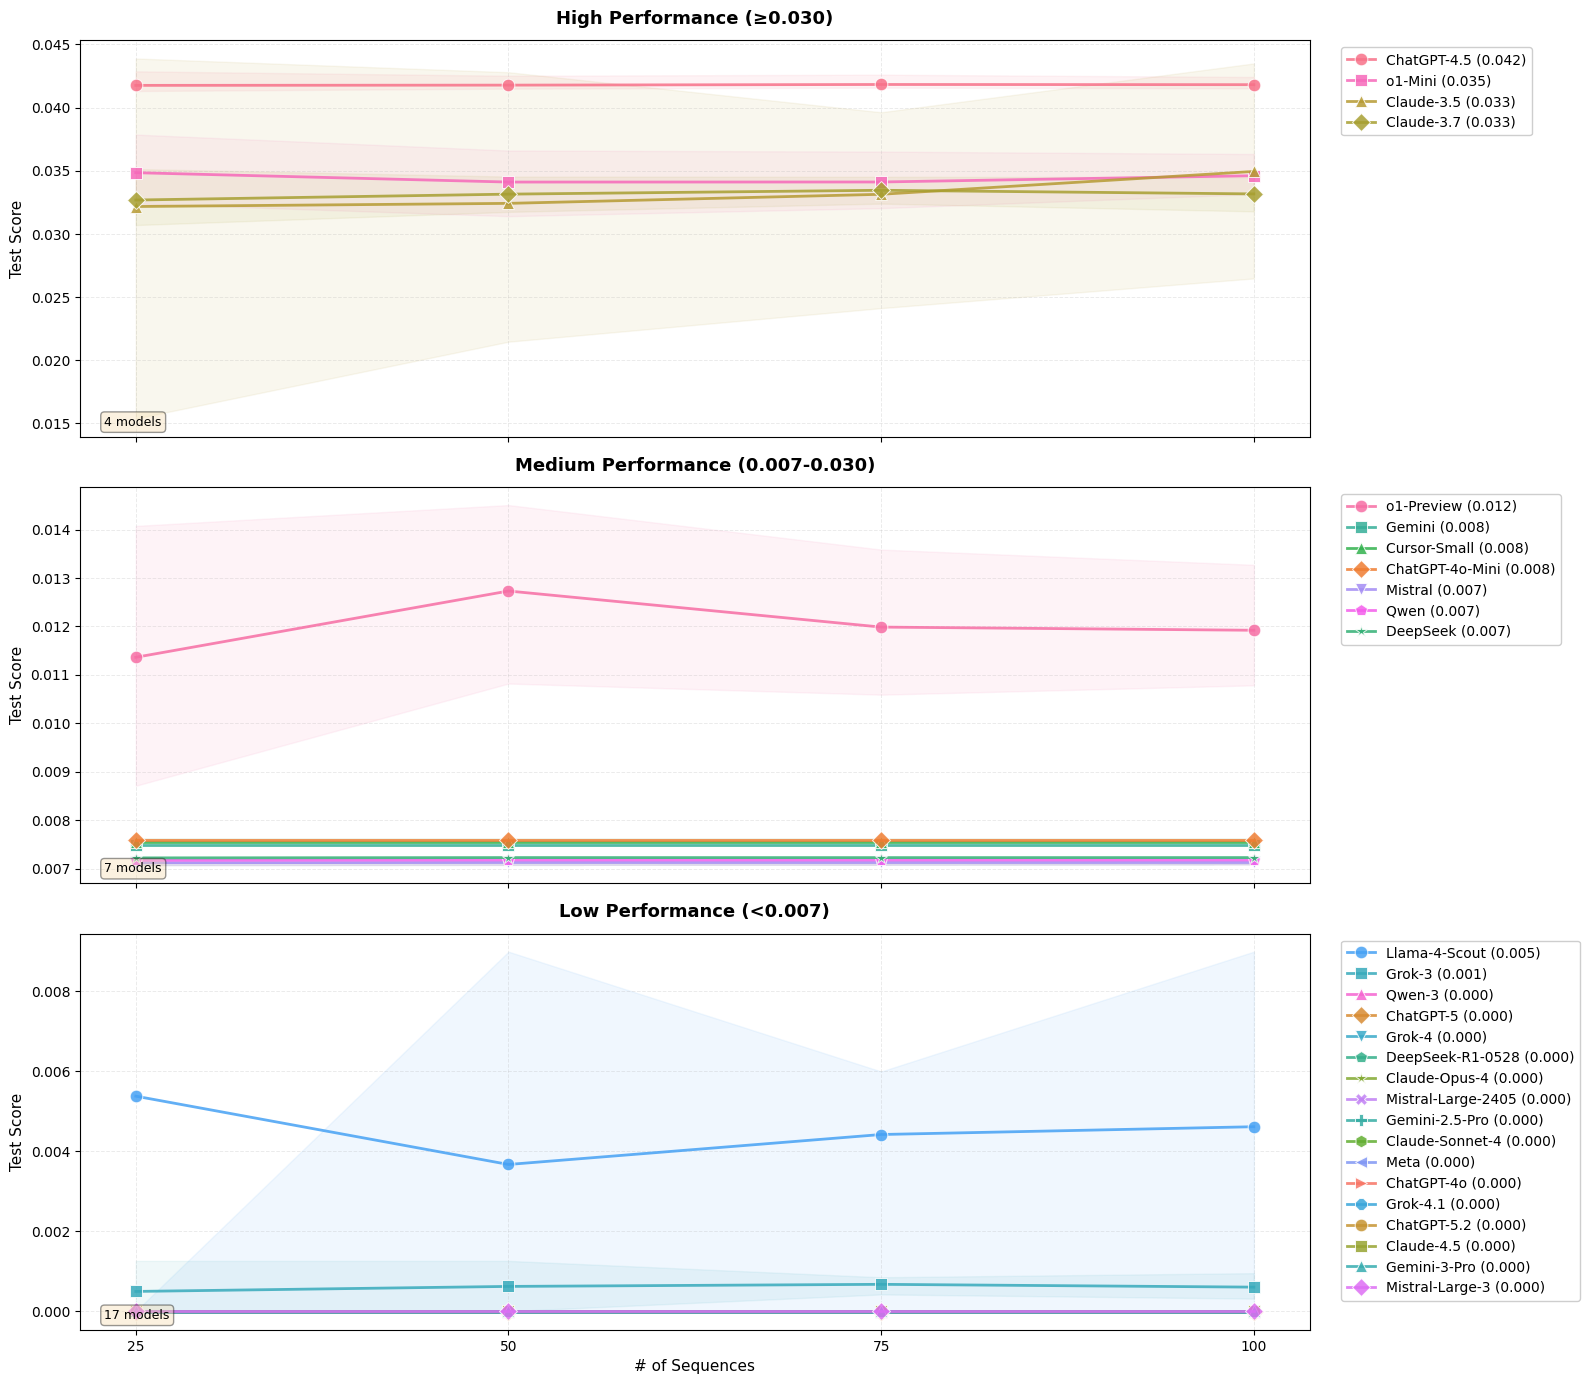


Model Performance Summary by Tier:

High Performance (≥0.030) (4 models):
  • ChatGPT-4.5                     Mean: 0.041989  Std: 0.000888
  • o1-Mini                         Mean: 0.034515  Std: 0.003676
  • Claude-3.5                      Mean: 0.033165  Std: 0.015685
  • Claude-3.7                      Mean: 0.033011  Std: 0.002407

Medium Performance (0.007-0.030) (7 models):
  • o1-Preview                      Mean: 0.012174  Std: 0.002788
  • Gemini                          Mean: 0.007616  Std: 0.000000
  • Cursor-Small                    Mean: 0.007616  Std: 0.000000
  • ChatGPT-4o-Mini                 Mean: 0.007616  Std: 0.000000
  • Mistral                         Mean: 0.007099  Std: 0.000040
  • Qwen                            Mean: 0.007099  Std: 0.000040
  • DeepSeek                        Mean: 0.007099  Std: 0.000040

Low Performance (<0.007) (17 models):
  • Llama-4-Scout                   Mean: 0.004537  Std: 0.006927
  • Grok-3                          Mean: 0.0006

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# Your existing inner_loop_function and data processing code here
# (keeping it the same as your original)

def inner_loop_function(models,bin_seq_df):
    bdm = BDM(ndim=1,partition=PartitionRecursive)
    dict_tst={}
    for mdl in models:#[:-1]:
        sep_df= bin_seq_df[['sequence',f'{mdl}-formula',f'{mdl}-formula-correctness',f'{mdl}-formula-ordinal',f'{mdl}-formula-copy_seq']].copy()
        sep_df["bdm_formula"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df[f'{mdl}-formula'].to_numpy()]
        sep_df["bdm_input"]=[bdm.nbdm(ascii_to_binary_list(x)) for x in sep_df['sequence'].to_numpy()]
        df_c_n_n = sep_df[sep_df[f"{mdl}-formula-correctness"] & ~sep_df[f"{mdl}-formula-ordinal"] & ~sep_df[f"{mdl}-formula-copy_seq"]]
        df_c_o = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-ordinal"]]
        df_c_p = sep_df[sep_df[f"{mdl}-formula-correctness"] & sep_df[f"{mdl}-formula-copy_seq"]]
        df_i = sep_df[~sep_df[f"{mdl}-formula-correctness"]]
        tot_elements = np.sum([len(x) for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v1=np.array([len(x)/tot_elements for x in [df_c_n_n,df_c_o,df_c_p,df_i]])
        v2 = []
        for x in [df_c_n_n,df_c_o,df_c_p]:
            datax = np.tanh(((x["bdm_input"])/(x["bdm_formula"])).to_numpy())
            if len(datax)>0:
                v2.append(harmonic_mean(datax))
            else:
                v2.append(0)
        v2 = (np.nan_to_num(np.array(v2)))
        tst = tst_calc(v1,v2)
        dict_tst[mdl] = [tst]
    return dict_tst

np.random.seed(42)
rng = np.random.default_rng()
tst_bootstrap=[]
for sz in [25,50,75,100]:
    inpts_bts = []
    for rep_id in range(100):
        idx_v = rng.integers(low=0, high=100, size=sz,dtype = int)
        inpts_bts.append([models,bin_seqs.iloc[idx_v]])
    calcs_lst = Parallel(n_jobs=32)(delayed(inner_loop_function)(*x) for x in inpts_bts)
    dict_tst={}
    for mdl in models:
        dict_tst[mdl]=[]
    for dict_indiv in calcs_lst:
        for ddd in dict_indiv.keys():
            dict_tst[ddd]=dict_tst[ddd]+dict_indiv[ddd]
    tst_bootstrap.append(dict_tst)

lst_dfs=[]
for pp,sz in enumerate([25,50,75,100]): 
    df_interm = pd.DataFrame(tst_bootstrap[pp]).T.reset_index()
    df_interm = df_interm.melt(id_vars=['index'])
    df_interm.loc[:,'variable']=sz
    lst_dfs.append(df_interm)

df_bts = pd.concat(lst_dfs)
df_bts.columns = ["Model","# of Sequences","Test Score"]
# Map model names to display names
df_bts['Model'] = df_bts['Model'].apply(get_model_display_name)

# Calculate mean test score for each model
model_means = df_bts.groupby('Model')['Test Score'].mean().sort_values(ascending=False)

# Assign broad performance category
def assign_broad_tier(model_name):
    mean_score = model_means[model_name]
    if mean_score >= 0.030:
        return 'High'
    elif mean_score >= 0.007:
        return 'Medium'
    else:
        return 'Low'

df_bts['Broad_Tier'] = df_bts['Model'].apply(assign_broad_tier)

# Create the plot with 3 main tiers, but use offset plotting within each tier
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

tiers = ['High', 'Medium', 'Low']
tier_titles = {
    'High': 'High Performance (≥0.030)',
    'Medium': 'Medium Performance (0.007-0.030)',
    'Low': 'Low Performance (<0.007)'
}

# Create color palette
all_models = sorted(df_bts['Model'].unique())
colors = sns.color_palette("husl", len(all_models))
model_color_map = dict(zip(all_models, colors))

# Different markers
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X', 'P', 'h', '<', '>', '8']

for idx, tier in enumerate(tiers):
    tier_data = df_bts[df_bts['Broad_Tier'] == tier]
    tier_models = sorted(tier_data['Model'].unique(), 
                        key=lambda x: model_means[x], 
                        reverse=True)
    
    n_models = len(tier_models)
    
    if n_models == 0:
        axes[idx].text(0.5, 0.5, 'No models in this tier', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        continue
    
    # Calculate vertical offset to separate overlapping lines
    # Models will be slightly offset vertically for visibility
    for model_id, model in enumerate(tier_models):
        model_data = tier_data[tier_data['Model'] == model]
        
        # Calculate statistics
        mean_scores = model_data.groupby('# of Sequences')['Test Score'].mean()
        std_scores = model_data.groupby('# of Sequences')['Test Score'].std()
        ci_lower = model_data.groupby('# of Sequences')['Test Score'].quantile(0.25)
        ci_upper = model_data.groupby('# of Sequences')['Test Score'].quantile(0.75)
        
        # Apply small vertical offset based on position in sorted list
        # This spreads overlapping lines slightly
        offset_factor = 0.0001 if tier == 'High' else (0.00005 if tier == 'Medium' else 0.000002)
        vertical_offset = (model_id - n_models/2) * offset_factor
        
        # CHANGE 4: Create label with average in parentheses
        model_avg = model_means[model]
        label_with_avg = f"{model} ({model_avg:.3f})"
        
        # CHANGE 2: Increased markersize from 7 to 9.1 (30% bigger: 7 * 1.3 = 9.1)
        axes[idx].plot(
            mean_scores.index,
            mean_scores.values + vertical_offset,
            marker=markers[model_id % len(markers)],
            markersize=9.1,
            linewidth=2,
            label=label_with_avg,
            color=model_color_map[model],
            markeredgewidth=0.7,
            markeredgecolor='white',
            alpha=0.85
        )
        
        # Add very subtle confidence band (without offset for accuracy)
        axes[idx].fill_between(
            mean_scores.index,
            ci_lower.values,
            ci_upper.values,
            alpha=0.08,
            color=model_color_map[model]
        )
    
    # Formatting
    axes[idx].set_title(tier_titles[tier], fontsize=13, fontweight='bold', pad=12)
    axes[idx].set_ylabel('Test Score', fontsize=11)
    axes[idx].grid(True, alpha=0.25, linestyle='--', linewidth=0.7)
    
    # CHANGE 1: Always place High tier legend outside, adjust other tiers accordingly
    # CHANGE 3: Increased legend fontsize by 25% (9 * 1.25 = 11.25, 8 * 1.25 = 10)
    if tier == 'High':
        # Always place High performance legend outside the plot area
        axes[idx].legend(bbox_to_anchor=(1.02, 1), loc='upper left', 
                        fontsize=10, framealpha=0.95, ncol=1)
    elif n_models <= 6:
        axes[idx].legend(loc='best', fontsize=11.25, framealpha=0.95, ncol=1)
    else:
        axes[idx].legend(bbox_to_anchor=(1.02, 1), loc='upper left', 
                        fontsize=10, framealpha=0.95, ncol=1)
    
    # Add model count annotation
    axes[idx].text(0.02, 0.02, f'{n_models} model{"s" if n_models != 1 else ""}',
                  transform=axes[idx].transAxes,
                  fontsize=9, verticalalignment='bottom',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

axes[-1].set_xlabel('# of Sequences', fontsize=11)
axes[-1].set_xticks([25, 50, 75, 100])

plt.tight_layout()
plt.savefig("robustness_tst_faceted.png", bbox_inches='tight', dpi=600)
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure08.pdf", bbox_inches="tight")
plt.savefig("/Users/alberto/Documents/projects/medLLM/plots/highResolution/figure08.svg", bbox_inches="tight")
plt.show()

# Print summary statistics
print("\nModel Performance Summary by Tier:")
print("=" * 80)
for tier in tiers:
    tier_models = df_bts[df_bts['Broad_Tier'] == tier]['Model'].unique()
    if len(tier_models) > 0:
        print(f"\n{tier_titles[tier]} ({len(tier_models)} models):")
        for model in sorted(tier_models, key=lambda x: model_means[x], reverse=True):
            mean = model_means[model]
            std = df_bts[df_bts['Model'] == model]['Test Score'].std()
            print(f"  • {model:30s}  Mean: {mean:.6f}  Std: {std:.6f}")